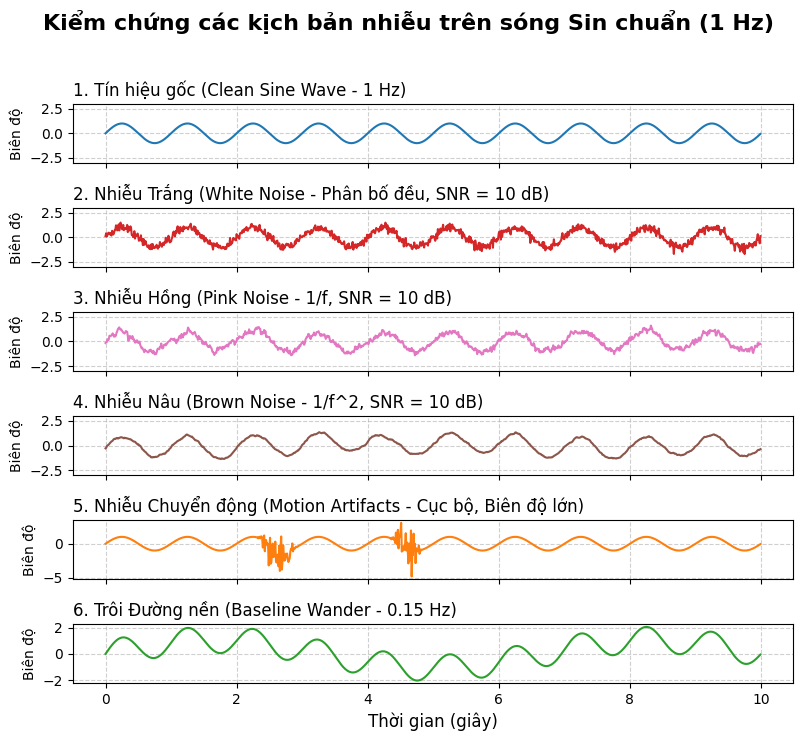

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Đưa đường dẫn thư mục gốc vào hệ thống để gọi module core_ntsa
sys.path.append(os.path.abspath(".."))
from core_ntsa.noise_tools import (
    add_white_noise, 
    add_colored_noise, 
    add_motion_artifacts, 
    add_baseline_wander
)

# 1. TẠO TÍN HIỆU GỐC (Sóng Sin Chuẩn)
sampling_rate = 100.0  # Tần số lấy mẫu 100 Hz
t_span = 10.0          # Tổng thời gian 10 giây
t = np.arange(0, t_span, 1.0 / sampling_rate)

# Sóng sin 1 Hz (1 chu kỳ / giây), biên độ 1
clean_signal = np.sin(2 * np.pi * 1.0 * t)

# 2. BƠM CÁC KỊCH BẢN NHIỄU
# Kịch bản 1: Nhiễu trắng (SNR = 10 dB)
signal_white = add_white_noise(clean_signal, snr_db=10.0)

# Kịch bản 2: Nhiễu hồng 1/f (SNR = 10 dB)
signal_pink = add_colored_noise(clean_signal, snr_db=10.0, color='pink')

# Kịch bản 3: Nhiễu nâu 1/f^2 (SNR = 10 dB)
signal_brown = add_colored_noise(clean_signal, snr_db=10.0, color='brown')

# Kịch bản 4: Nhiễu chuyển động (2 cụm nhiễu cục bộ, biên độ gấp 3 lần tín hiệu)
signal_motion = add_motion_artifacts(
    clean_signal, 
    num_artifacts=2, 
    max_length=80, 
    amplitude_ratio=3.0
)

# Kịch bản 5: Trôi đường nền (Tần số siêu thấp 0.15 Hz, biên độ gấp 1.5 lần)
signal_wander = add_baseline_wander(
    clean_signal, 
    frequency=0.15, 
    sampling_rate=sampling_rate, 
    amplitude_ratio=1.5
)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
# Tăng figsize để đủ không gian cho 6 đồ thị
fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
fig.suptitle("Kiểm chứng các kịch bản nhiễu trên sóng Sin chuẩn (1 Hz)", fontsize=16, fontweight='bold', y=0.92)

# Các thông số vẽ để dùng chung trong vòng lặp
signals = [clean_signal, signal_white, signal_pink, signal_brown, signal_motion, signal_wander]
colors = ['#1f77b4', '#d62728', '#e377c2', '#8c564b', '#ff7f0e', '#2ca02c'] # Thêm màu nâu (#8c564b)
titles = [
    "1. Tín hiệu gốc (Clean Sine Wave - 1 Hz)",
    "2. Nhiễu Trắng (White Noise - Phân bố đều, SNR = 10 dB)",
    "3. Nhiễu Hồng (Pink Noise - 1/f, SNR = 10 dB)",
    "4. Nhiễu Nâu (Brown Noise - 1/f^2, SNR = 10 dB)",
    "5. Nhiễu Chuyển động (Motion Artifacts - Cục bộ, Biên độ lớn)",
    "6. Trôi Đường nền (Baseline Wander - 0.15 Hz)"
]

for i, ax in enumerate(axes):
    ax.plot(t, signals[i], color=colors[i], linewidth=1.5)
    ax.set_title(titles[i], fontsize=12, loc='left')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel("Biên độ")
    
    # Đồng bộ trục Y để dễ so sánh giữa tín hiệu sạch và 3 loại nhiễu nền
    if i < 4:
        ax.set_ylim(-3.0, 3.0)

axes[-1].set_xlabel("Thời gian (giây)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## Đánh giá Thực nghiệm: Tác động của các Kịch bản Nhiễu lên Tín hiệu Tuần hoàn

Biểu đồ trên trình bày kết quả mô phỏng 5 kịch bản nhiễu điển hình tác động lên một sóng sin chuẩn (tần số 1 Hz). Việc hiểu rõ đặc tính hình thái của từng loại nhiễu là cơ sở bắt buộc trước khi đưa các thuật toán Động lực học phi tuyến (NTSA) vào kiểm thử trên dữ liệu thực tế.

### 1. Nhiễu Trắng (White Noise)
* **Đặc điểm:** Phân bố năng lượng đồng đều trên mọi dải tần số. Các giá trị nhiễu độc lập hoàn toàn với nhau theo thời gian.
* **Biểu hiện hình thái:** Tạo ra các gai nhọn (fuzz) lởm chởm bám sát theo bề mặt của sóng gốc. Tín hiệu vẫn giữ được hình dạng chu kỳ rõ ràng và không bị lệch khỏi trục 0.
* **Tác động lên NTSA:** Thường làm tăng giả tạo số chiều không gian nhúng ($m$) trong thuật toán False Nearest Neighbors (FNN), nhưng dễ dàng bị loại bỏ bằng các bộ lọc thông thấp (Low-pass filter) truyền thống.

### 2. Nhiễu Hồng (Pink Noise - $1/f$)
* **Đặc điểm:** Năng lượng tỷ lệ nghịch với tần số. Các thành phần tần số thấp mang nhiều năng lượng hơn.
* **Biểu hiện hình thái:** Tín hiệu có sự "bồng bềnh" và xuất hiện các xu hướng cục bộ (local trends). Mặc dù cùng mức $SNR = 10 \text{ dB}$ với nhiễu trắng, nhiễu hồng làm độ gập ghềnh của các đỉnh sóng trở nên bất quy tắc hơn.
* **Tác động lên NTSA:** Cực kỳ nguy hiểm. Nhiễu hồng sở hữu cấu trúc tương quan thời gian dài (long-range correlation) mang bản chất phân dạng (fractal). Nó rất dễ đánh lừa các thuật toán tính Entropy hoặc Lyapunov Exponent, khiến hệ thống nhầm lẫn giữa nhiễu ngẫu nhiên và hỗn mang tất định.

### 3. Nhiễu Nâu (Brown Noise - $1/f^2$)
* **Đặc điểm:** Năng lượng tập trung cực mạnh ở các dải tần số siêu thấp, mang đặc trưng của "bước đi ngẫu nhiên" (Random Walk).
* **Biểu hiện hình thái:** Phá vỡ hoàn toàn trạng thái cân bằng của tín hiệu gốc. Sóng sin bị kéo trôi dạt (drifting) ngẫu nhiên lên xuống với biên độ lớn, làm mất đi các điểm cắt không (zero-crossing points) chu kỳ.
* **Tác động lên NTSA:** Gây ra tính phi dừng (non-stationarity) nghiêm trọng. Yêu cầu bắt buộc phải sử dụng các kỹ thuật khử xu hướng (như Detrended Fluctuation Analysis - DFA) trước khi trích xuất đặc trưng.

### 4. Nhiễu Chuyển động (Motion Artifacts)
* **Đặc điểm:** Các xung nhiễu (bursts) xuất hiện cục bộ với biên độ đột biến, phần còn lại của tín hiệu vẫn sạch. 
* **Biểu hiện hình thái:** Phản ánh chính xác các sự cố cơ học trong thu thập dữ liệu (ví dụ: cảm biến quang dung tích PPG bị xô lệch trên da người dùng khi có thao tác tay đột ngột).
* **Tác động lên NTSA:** Phá nát hoàn toàn hình học của không gian pha tại thời điểm xảy ra xung nhiễu. Gây sai lệch nghiêm trọng cho các thuật toán dò đỉnh (Peak Detection) để tính chu kỳ tín hiệu.

### 5. Trôi Đường nền (Baseline Wander)
* **Đặc điểm:** Dao động hình sin với tần số cực thấp (0.15 Hz).
* **Biểu hiện hình thái:** Tín hiệu gốc bị "nhấc bổng" và "hạ thấp" theo một chu kỳ dài. Đại diện cho các tác động sinh lý mang tính nhịp điệu chậm (như chu kỳ hô hấp của lồng ngực làm thay đổi khoảng cách cảm biến).
* **Tác động lên NTSA:** Làm méo mó quỹ đạo trong không gian pha, biến một Attractor (bộ hấp dẫn) ổn định thành một cấu trúc bị kéo giãn theo không gian.